In [ ]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats




sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')
import plot_settings
import importlib
#import multi_exp_log
#import Param_symbol

import GP
import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib


from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(GP)
    importlib.reload(_lib)

COLORS = plot_settings.colors()

import_reload()
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
GP_FIT = GP.GP_process()

In [ ]:
# ––––––––––––– Obtain elements –––––––––––––
c_rate = [2.0, 2.0]       # List or not list is ok
u_per  = [5, 5]
soc    = [0.7, 0.8]


# –––––––––––– Dispatchers ––––––––––––––––
# Alternaitvely load model as GLOBAL
model_name = 'ecm_node_0430_1313_staged_swelling_netR0_25.28min_32h_2000_100_S2b20eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)
# history, CONFIG, C1_final, N_HIDDEN, EPOCHS_STATIC, EPOCHS_DYNAMIC, EPOCHS_UNFREEZE = load_checkpoint(ckpt)

def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

R0 = R0_nn(c_rate, u_per, soc)
R1 = R1_nn(c_rate, u_per, soc)
C1 = C1_nn(c_rate, u_per, soc)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 32, 'R1_constrained': 'true', 'R1_min': 0.005, 'R1_max': 0.2, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 50000.0, 'R0_constrained': 'true', 'R0_min': 0.008, 'R0_max': 0.015}
Using I_ref = 24.79
R1 constrained to [0.005, 0.2] Ohm
C1 unconstrained
R0 constrained to [0.008, 0.015] Ohm


Loading symbolic regression results for RUN_ID: all1


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

k_ref: 3.18588 GN/mm


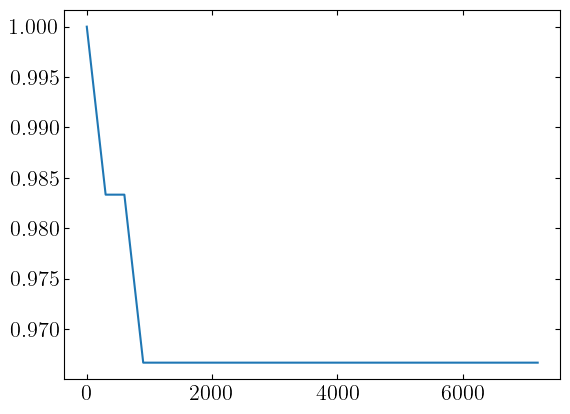

In [ ]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats




sys.path.append('../..')
sys.path.append('..')
sys.path.append('../nodes_2')
import plot_settings
import importlib


from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(GP)
    importlib.reload(_lib)


import_reload()
# Importing data
RUN_ID = 'all1'
DT = 1
Q0 = 17921.57581 
## ECM solver module
# Extract expressions from symbolic regression results
def extract_expressions(run_id):
    # Load the symbolic regression results
    elements = ['k', 'R1', 'C1']
    
    expressions = {}

    for elem in elements:
    
        results_path = Path(f'sr_models/model_{elem}_{run_id}.csv')
        if not results_path.exists():
            raise FileNotFoundError(f"Results file not found: {results_path}")
    
        results_df = pd.read_csv(results_path)

        expr = results_df['sympy_format'][int(results_df['complexity'].idxmax()/2)]# == int(results_df['complexity'].mean())]


        sym_expr = sp.sympify(expr)
        expressions[elem] = sym_expr

        
    
    return expressions['k'], expressions['R1'], expressions['C1']

print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
k_expr, R1_expr, C1_expr = extract_expressions(RUN_ID)

display(Math('\\LARGE x_0 = \\mathrm{{C\\,rate}}\\quad x_1 = \\widetilde{d}\\quad x_2 = \\mathrm{{SOC}}'))
display(Math(f'\\LARGE f_{{C_1}}(x_0,x_1,x_2) = {sp.latex(C1_expr)}'))
display(Math(f'\\LARGE f_{{R_1}}(x_0,x_1,x_2)= {sp.latex(R1_expr)}'))
display(Math(f'\\LARGE f_k\\,(x_0,x_1,x_2) = {sp.latex(k_expr)}'))

k_func = sp.lambdify(('x0', 'x1', 'x2'), k_expr, 'numpy')
R1_func = sp.lambdify(('x0', 'x1', 'x2'), R1_expr, 'numpy')
C1_func = sp.lambdify(('x0', 'x1', 'x2'), C1_expr, 'numpy')

def read_data(file_name):
    df = pd.read_csv(
        f"symbol_data/{file_name}.txt",
        sep=',',
        comment="%"
    )

    return df


path = f'ecm_node_elements_0429_1012_staged_funcR0_unconstr_pulse_1.32min_32h_1000_0eps'

data = read_data(path)

data['k'] = data['k'] * 100
k_ref = data['k'].mean() 
print(f'k_ref: {k_ref:.5f} GN/mm')
REF_VALUES = {
    'R1': 0.01,
    'C1': 1000,
    'k': k_ref}
import scipy.signal as signal

def R0(i, d, SOC):
    return 0.01

def R1(i, d, SOC,R1_func = R1_func, Ref= REF_VALUES):
    return R1_func(i, d, SOC) * Ref['R1']

def C1(i, d, SOC,C1_func = C1_func, Ref= REF_VALUES):
    return C1_func(i, d, SOC) * Ref['C1']

def k(i, d, SOC):
    return k_func(i, d, SOC) * REF_VALUES['k']/100 


def time_current_profile(C_rate,mode = 'DC'):
    I_0 = C_rate * Q0 / 3600
    if mode == 'DC':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = I_0 * np.ones_like(t)
        return I,t
    elif mode == 'pulse':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = signal.square(2 * np.pi * t / (3600 / C_rate)) * I_0 / 2 + I_0 / 2
        return I,t

def pulse_current_profile(t, C_rate, period = 600):
    I_0 = C_rate * Q0 / 3600 * 0.2
    I = I_0 * (signal.square(2 * np.pi * t / period) + 1)/2
    return I

def ECM_solve_du(u_par,C_rate, RC2 = False, U0 = 0, discharge = True, mode = 'DC'):
    
    t = np.arange(0, 2 * int(3600 / C_rate), DT)


    if mode == 'pulse':
        def I_interp(t):
            return pulse_current_profile(t, C_rate)
    else:
        i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity
        I_interp = interp1d(t, i, fill_value="extrapolate")

    i = I_interp(t)
    if not discharge:
        i = -i
        soc0 = 0
    else:        
        soc0 = 1

    def dSOC(SOC, t, C_rate=C_rate, u_par=u_par):
        I_t = pulse_current_profile(t, C_rate)
        return -I_t / Q0
    
    
    def SOC(t,SOC0=soc0):
        SOC_t = scipy.integrate.odeint(dSOC, SOC0, t).flatten()
        return SOC_t
    
    SOC_t = SOC(t)
    plt.plot(t, SOC_t)
    plt.show()
    soc_interp = interp1d(t,SOC_t,bounds_error=False,fill_value=(SOC_t[0], SOC_t[-1]))

    def dU(V_1, t, soc_int = soc_interp, d = u_par):
        I_t = pulse_current_profile(t, C_rate)
        SOC_t = soc_int(t)
        if not discharge:
            SOC_t = 1 - SOC_t
        R = R1(C_rate, d, SOC_t)
        C = C1(C_rate, d, SOC_t)
        return -V_1 / (R * C) + I_t / C 
    
    def mech(t, soc_int = soc_interp, d = u_par):
        SOC_t = soc_int(t)
        return k(C_rate, d, SOC_t)*d

    # Solve ODE
    
    U1 = scipy.integrate.odeint(dU, U0, t).flatten()


    U = U1 #+ U2
    # Voltage model
    eta_model =  i*R0(C_rate,u_par,SOC_t) + U
    V_B = GP.soc_to_Ue(SOC_t, GP_FIT) - eta_model

    if not discharge:
        valid_inds = V_B< 5.8
    else:
        valid_inds = V_B> 2.3
    V_B = V_B[valid_inds]
    t = t[valid_inds]
    soc = SOC_t[valid_inds]
    Ue = GP.soc_to_Ue(soc, GP_FIT)
    i = I_interp(t)

    return V_B,soc, Ue,i ,t, mech(t)


# for C_rate in np.arange(0.5, 2, 0.5):
#     V_B,soc,Ue,i,t,F = ECM_solve_du(1,C_rate, discharge=True, mode = 'DC')
#     plt.plot(soc, V_B, label=f'C={C_rate}x')
# plt.plot(np.linspace(0,1,100), GP.soc_to_Ue(np.linspace(0,1,100), GP_FIT), color = 'k',ls = '--', label='True $U_e$')
# plt.show()

# for u in np.arange(1, 29, 5):
#     V_B,soc,Ue,i,t,F = ECM_solve_du(u,2)
#     plt.scatter(u, F.min(), label=f'u={u}')
#     plt.scatter(u, F.max(), label=f'u={u}')

V_B,soc,Ue,i,t,F = ECM_solve_du(1,1, discharge = True, mode = 'DC')